# Scientific Programming with Python 
## (Winter 2025/26)

# Session 04: MatPlotLib

* Organization
* Some more python
* MatPlotLib

# Organization


## Exercise groups

1.) All of the groups now have 6 spots instead of 4 spots and new people can join the existing groups until Friday, October 31, 11:59:00.  

2.) Moving forward, we have decided that each group of 6 members will be divided further into two subgroups of 3 people each. The group members will decide themselves which subgroup they want to be a part of. Each subgroup will meet with their responsible TAs once every two weeks and discuss their homework solutions. For example:- If group 1 has 6 members, then these 6 members will divide themselves into 2 subgroups of 3 people each. Subgroup A will meet their responsible TA in the first week and Subgroup B will meet with their responsible TA in the second week. You are also free to choose different subgroup sizes as long as everyone agrees with the subgroup division and the workload is equally divided between all the subgroup members.

3.) If a group has 5 members in total , then one subgroup will have 2 members and the other will have 3 members. For groups consisting of 4 people total, the subgroup division will be equal, i.e. each subgroup will contain 2 people.

4.) For groups which will have only 3 people in total, there won't be a need to form subgroups and these 3 members can work together.

5.) Each member of a subgroup needs to work on only one part of the total exercise sheet, because working on the whole sheet by oneself might lead to a lot more work than intended by us. This is a 4 ECTS ungraded course, so the workload per person per week should be similar to other 4 ECTS courses. For example: if one exercise sheet has 3 problems in total and there are 3 members in a subgroup, then one member is expected to work on only 1 problem as per prior agreement with others present in the same subgroup. After this, all the subgroup members are expected to meet with each other and discuss the whole exercise sheet and the individual problems which one person hasn't solved.

6.) We have decided to release one exercise sheet per 2 weeks, so that every subgroup gets more time to understand and solve the respective exercise sheets. Again, I mention that 1 person in a subgroup needs to work only on a part of the whole exercise sheet and not the entire sheet by themselves.

7.) Each subgroup must submit their bi-weekly assignment solutions to the designated Group folder which they are part of. For example:- if both subgroup A and subgroup B are part of Group 1, then Subgroup A will submit only one solution for the whole subgroup in their designated Group homework submission folder and subgroup 2 will do the same. Please don't submit individual solutions like a lot of people have done so far.

8.) All subgroups need to submit (N-1) exercise sheets in order to be eligible for implementing the Final Group Project and getting the 4 ECTS credit points at the end. All the subgroup members also need to join (N-1) TA meetings and discuss their implemented individual solutions and ask questions (if needed), in order to be able to participate in the Final Group Project. More information about the Final Project will be announced in due time.

9.) The new students who joined the groups after we increased the group sizes to 6 members should submit the first homework assignment by the due date of the second homework assignment. The new members in a group can also form a subgroup amongst themselves and then submit the first assignment solution together before the deadline of the second assignment or they can form subgroups with the prior existing members of that whole group and then submit the first assignment solution individually by themselves. The new members should also mention in their first assignment solution that they joined the group late and hence, submitting the first assignment by the deadline of the second assignment.

10.) Finally, the bi-weekly meetings between the subgroups and their responsible TAs are meant to enhance the students' understanding of Python and its associated libraries as discussed in the lectures by Ulf, by means of discussing solutions and asking questions. The meetings happen in a gentle and informal setting and no one will be penalized for not understanding some concept or for asking some trivial question. Therefore, we encourage everyone to freely participate in the meetings.

## Tutor meetings

There will be initial tutor meetings this week. Meetings can be online or onsite - discuss with your tutor.  For in-person meetings, we have the following rooms:
* Wed., 12:00 - 14:00  Room: 93/E01
* Wed., 14:00 - 16:00  Room: 93/E12
* Thu., 12:00 - 14:00  Room: 35/E22
online meetings on Friday in BBB

At the meeting:
* present your solutions to the exercises
* questions & answers
* feedback

# New exercise sheet

New exercise sheet (MatPlotLib): sheet03 (due before November 11th)

# Python: Iterables and Iterators

Objects that can be used in `for ... in ...` statements are called *iterable*.

In [30]:
class Triple:
    def __init__(self, num1, num2, num3):
        self.nums = num1, num2, num3
    
    def __repr__(self):
        """A string representation for inspecting objects at runtime."""
        return "Triple(" + str(self.nums[0]) + ", " + str(self.nums[1]) + ", " + str(self.nums[2]) + ")"
    
    def __iter__(self):
        return iter(self.nums)
    
my_triple = Triple(1, 2, 3)

for value in my_triple:
    print(value)

1
2
3


The `__iter__` - magic-method is what makes an object iterable. Behind the scenes, the `iter`-function calls this method to get the iterator.

An *iterator* is an object that implements `__next__`. 

In [11]:
class myrange:
    def __init__(self, n):
        self.i = 0
        self.n = n

    def __next__(self):
        if self.i < self.n:
            self.i += 1
            return self.i
        else:
            raise StopIteration()

The `next` method allows to provide the next element from the range:

In [15]:
a = myrange(2)

print(next(a))

1


In [16]:
print(next(a))

2


In [17]:
print(next(a))

StopIteration: 

While an Iterator allows to iterate elements, a pure Iterator can not be used in a `for` loop:

In [ ]:
a = myrange(2)
for i in a:
    print(i)

TypeError: 'myrange' object is not iterable

Usually, you want to make an iterator also iterable by returning itself from `__iter__`. Here an example of how to create your own `range`-function:

In [13]:
class myrange:
    def __init__(self, n):
        self.i = 0
        self.n = n

    def __iter__(self):
        return self

    def __next__(self):
        if self.i < self.n:
            self.i += 1
            return self.i
        else:
            raise StopIteration()

In [34]:
for i in myrange(5):
    print(i)

1
2
3
4
5


Understanding the `for` loop:

In [ ]:
iterable = range(4)

for element in iterable:
    # do something with element
    print(element)

What Python does internally roughly is roughly sketched by the following code:

In [ ]:
iterator = iter(iterable)
while True:
    try:
        element = next(iterator)
        # do something with element
        print(element)
    except StopIteration:
        break

0
1
2
3
0
1
2
3


Python relies heavily on iterators, and you should use them everytime Python offers them! the following code would be considered *unpythonic*.

In [35]:
a_list = [10, 20, 30]
for i in range(len(a_list)):
    print(a_list[i])

10
20
30


Instead we prefer using the iterator directly.

In [36]:
a_list = [10, 20, 30]
for number in a_list:
    print(number)

10
20
30


## Buildin functions that operator on `Iterables`

Besides the `for` loop, Python also has some buildin functions that work on operators:

The `zip` function takes multiple iterators and creates an iterator of tuples:

In [17]:
list(zip([1, 2, 3], ['a', 'b', 'c']))
[(1, 'a'), (2, 'b'), (3, 'c')]

[(1, 'a'), (2, 'b'), (3, 'c')]

`zip` can also zip more than two iterators:

In [20]:
list(zip(['US', 'Germany'], ['Washington', 'Berlin'], ['English', 'German']))

[('US', 'Washington', 'English'), ('Germany', 'Berlin', 'German')]

`map` takes a function and applies it to all elements of an iterator:

In [18]:
list(map(len, ['abc', 'de', 'fghi']))

[3, 2, 4]

The `enumerate` function produces pairs:

In [24]:
list(enumerate('abc'))

[(0, 'a'), (1, 'b'), (2, 'c')]

This can be used if you need the index of an item in a `for` loop:

In [ ]:
word = 'abc'
for idx in range(len(word)):
    print(idx, word[idx])

In [ ]:
# better (does not require 'len' and '[]'):
for idx, item in enumerate('abc'):
    print(idx, item)

## Itertools

Python [`itertools`](https://docs.python.org/3/library/itertools.html) module implements a number of iterator building blocks inspired by constructs found in other programming languages, recasting them in a form suitable for Python. The module standardizes a core set of fast, memory efficient tools that are useful by themselves or in combination.

In [22]:
x = [1, 2, 3, 4, 5]
y = ['a', 'b', 'c']

list(zip(x, y))

[(1, 'a'), (2, 'b'), (3, 'c')]

In [23]:
import itertools

list(itertools.zip_longest(x, y))

[(1, 'a'), (2, 'b'), (3, 'c'), (4, None), (5, None)]

Itertools infinite iterators:

In [2]:
import itertools

for idx, value in enumerate(itertools.count(10)):
    if idx > 5:
        break
    print(value)

10
11
12
13
14
15


In [3]:
import itertools

for idx, value in enumerate(itertools.cycle('ABC')):
    if idx > 5:
        break
    print(value)

A
B
C
A
B
C


Combination of iterators:

In [5]:
list(itertools.chain("ABC", range(2)))

['A', 'B', 'C', 0, 1]

In [4]:
list(itertools.product("ABC", range(2)))

[('A', 0), ('A', 1), ('B', 0), ('B', 1), ('C', 0), ('C', 1)]

## Summary: Iterables

* Iterables are used frequently in Python
  - they allow for compact and often also efficicient code
* Check out the [`itertools` documentation](https://docs.python.org/3/library/itertools.html):
  - it offers many more functions that can be used for creating and utilizing iterators
* Provide Iterator/Iterable functionality for your own classes whenever reasonable
  - this allows your code to seemlessly integrate into existing frameworks

## Exercise

1. Write a class that can iterate the [Fibonacci sequence](https://en.wikipedia.org/wiki/Fibonacci_sequence) up to its $n$-th element.

2. Write a length function that can operator on iterators, by counting how many elements they provide.  Test it with the `myrange` class from above (note that `len(myrange(5))` does not work)

3. Write a program that outputs all permutations of a given string: `permute('ABC') `should yield: `ABC`, `ACB`, `BAC`, `BCA`, `CAB`, `CBA` (not necessary in that order).
  * a) Start by looking up the `itertools` documentation for a suitable function (you may have to add some extra trick to turn tuples back into strings)
  * b) Implement your own class that can generate such permutations (without itertools)

# Matplotlib

## Input Data: 1D Series

Let's move on to a couple of common plot types.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Basic Plotting

`plot` draws points with lines connecting them.  `scatter` draws unconnected points, optionally scaled or colored by additional variables.

As a basic example:

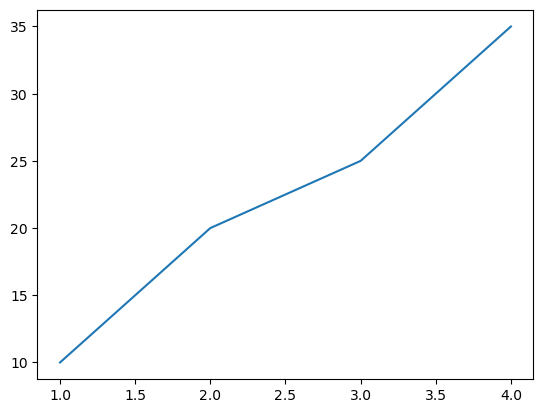

In [2]:
fig = plt.figure()
plt.plot([1, 2, 3, 4], [10, 20, 25, 35])
plt.show()

Multiple calls to the plot function will result in multiple plots. This works with many functions in mpl (plot, scatter, bar, etc.) and assigns different colors to the different calls.

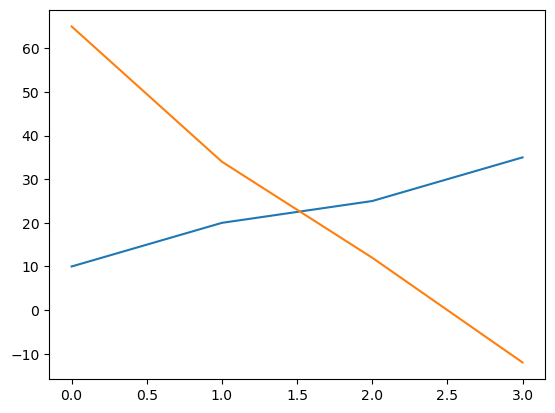

In [3]:
fig = plt.figure()
plt.plot([10, 20, 25, 35])
plt.plot([65, 34, 12, -12])
plt.show()

A matplotib figure can be stored as an image or PDF file:

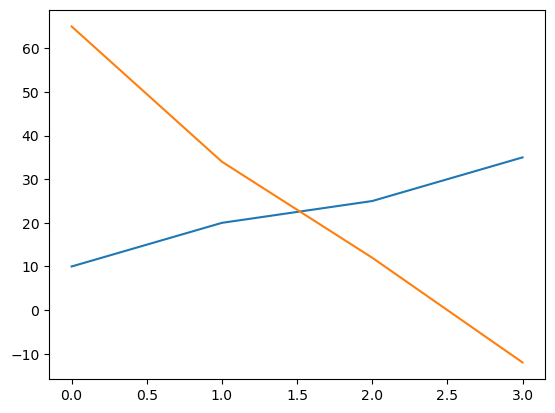

In [49]:
fig = plt.figure()
plt.plot([10, 20, 25, 35])
plt.plot([65, 34, 12, -12])

fig.savefig('myplot.png', dpi=300)
fig.savefig('pdf.png')

plt.show()

### Bar Plots: `ax.bar(...)` and `ax.barh(...)`

Bar plots are one of the most common plot types.  Matplotlib's `ax.bar(...)` method can also plot general rectangles, but the default is optimized for a simple sequence of x, y values, where the rectangles have a constant width.  There's also `ax.barh(...)` (for horizontal), which makes a constant-height assumption instead of a constant-width assumption.

### Simple bar plot

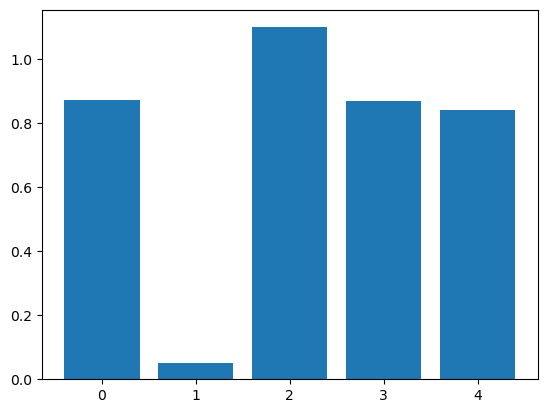

In [4]:
np.random.seed(2)
x = np.arange(5)
y = np.random.random(5) * 2

fig = plt.figure()
plt.bar(x, y)
plt.show()

In [5]:
x

array([0, 1, 2, 3, 4])

In [6]:
y

array([0.8719898 , 0.05185246, 1.09932496, 0.87064479, 0.8407356 ])

Adding errorbars...

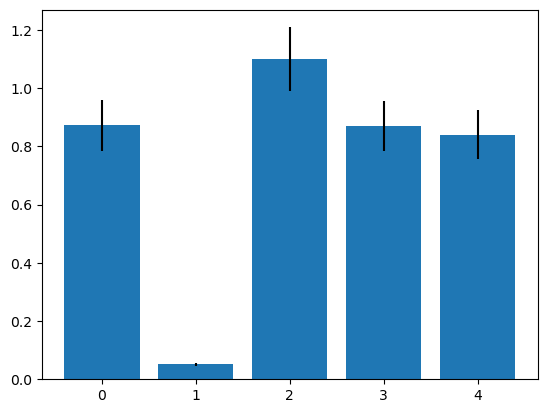

In [7]:
np.random.seed(2)
x = np.arange(5)
y = np.random.random(5) * 2
error = y * 0.1

fig = plt.figure()
plt.bar(x, y, yerr=error)
plt.show()

If we have negative values, we can use `axhline` to draw an axis "spine" to mark the zero line.

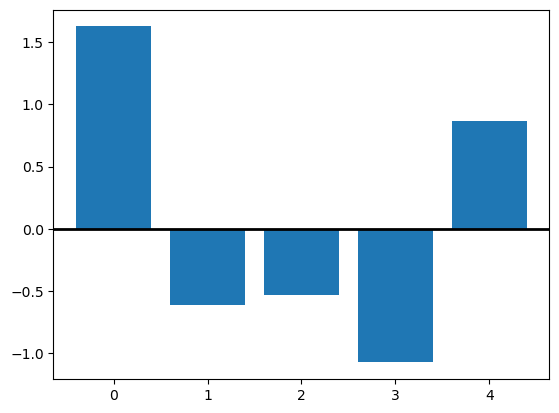

In [10]:
np.random.seed(1)
x = np.arange(5)
y = np.random.randn(5)

fig = plt.figure()
plt.bar(x, y)
plt.axhline(y=0, color='black', linewidth=2)
plt.show()

### Artists

* Matplotlib plotting methods return an `Artist` (or a sequence of artists)
* Anything you can see in a Matplotlib figure/axes/etc is an `Artist` of some sort.
* Most of the time, you will not need to retain these returned objects.
* You will want to capture them for special customizing that may not be possible through the normal plotting mechanism.

Let's re-visit that last example and modify what's plotted.  In the case of `bar`, a container artist is returned, so we'll modify its contents instead of the container itself (thus, `for bar in vert_bars`).

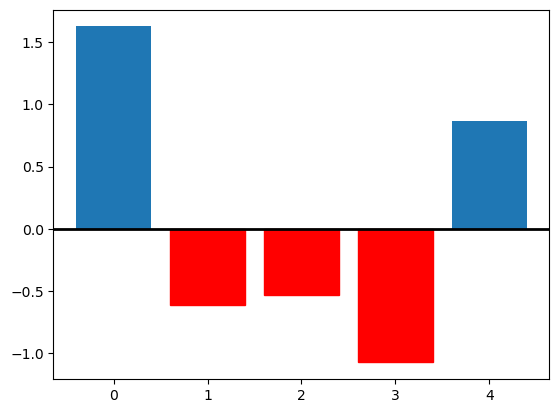

In [11]:
fig = plt.figure()
vert_bars = plt.bar(x, y) # Store the output of the call to .bar

for bar, height in zip(vert_bars, y):
    if height < 0:
        bar.set(color='red')

plt.axhline(y=0, color='black', linewidth=2)
plt.show()

Looking at the artist returned by `ax.bar` we can see that they are all plain rectangles.

In [12]:
for bar in vert_bars:
    print(bar)

Rectangle(xy=(-0.4, 0), width=0.8, height=1.62435, angle=0)
Rectangle(xy=(0.6, 0), width=0.8, height=-0.611756, angle=0)
Rectangle(xy=(1.6, 0), width=0.8, height=-0.528172, angle=0)
Rectangle(xy=(2.6, 0), width=0.8, height=-1.07297, angle=0)
Rectangle(xy=(3.6, 0), width=0.8, height=0.865408, angle=0)


Remark: we could have also done this with two separate calls to `plt.bar` and numpy boolean indexing:

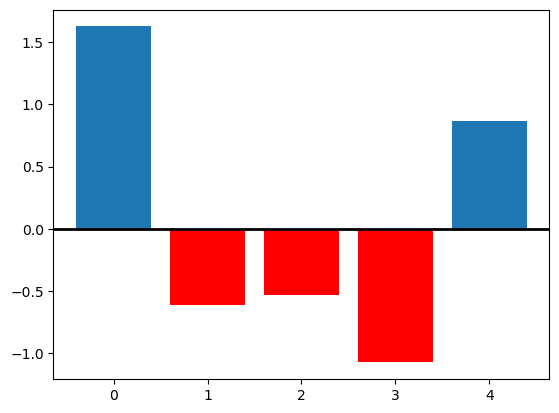

In [13]:
fig = plt.figure()
plt.bar(x[y>0], y[y>0])
plt.bar(x[y<0], y[y<0], color='red')
plt.axhline(y=0, color='black', linewidth=2)
plt.show()

### Filled Regions: `fill(x, y)`, `fill_between(...)`, etc

Of these functions, `plt.fill_between(...)` is probably the one you'll use the most often.  In its most basic form, it fills between the given y-values and 0:

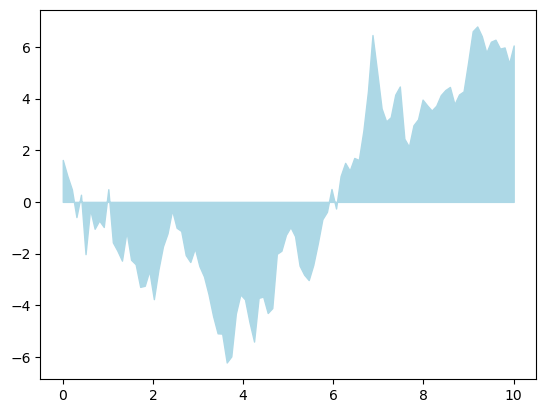

In [14]:
np.random.seed(1)
y = np.random.randn(100).cumsum()
x = np.linspace(0, 10, 100)

fig = plt.figure()
plt.fill_between(x, y, color='lightblue')
plt.show()

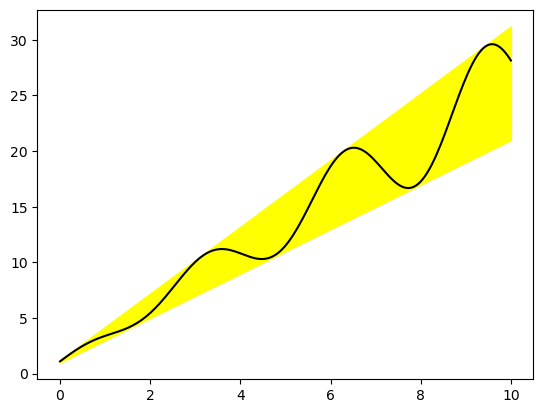

In [15]:
x = np.linspace(0, 10, 200)
y1 = 2 * x + 1
y2 = 3 * x + 1.2
y_mean = 0.5 * x * np.cos(2*x) + 2.5 * x + 1.1

fig = plt.figure()

# Plot the envelope with `fill_between`
plt.fill_between(x, y1, y2, color='yellow')

# Plot the "centerline" with `plot`
plt.plot(x, y_mean, color='black')

plt.show()

## Input Data: 2D Arrays or Images

There are several options for plotting 2D datasets.  `imshow`, `pcolor`, and `pcolormesh` have a lot of overlap, at first glance.  The image above is meant to clarify that somewhat.


In short, `imshow` can interpolate and display large arrays very quickly, while `pcolormesh` and `pcolor` are much slower, but can handle flexible (i.e. more than just rectangular) arrangements of cells.

We won't dwell too much on the differences and overlaps here.  They have overlapping capabilities, but different default behavior because their primary use-cases are a bit different (there's also `matshow`, which is `imshow` with different defaults).  

Instead we'll focus on what they have in common.

`imshow`, `pcolor`, `pcolormesh`, `scatter`, and any other Matplotlib plotting methods that map a range of data values onto a colormap will return artists that are instances of `ScalarMappable.`  In practice, what that means is 

a) you can display a colorbar for them, and

b) they share several keyword arguments.

### Displaying 2d data with `imshow`

In [16]:
arr_2d = np.arange(9).reshape((3, 3))
arr_2d

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

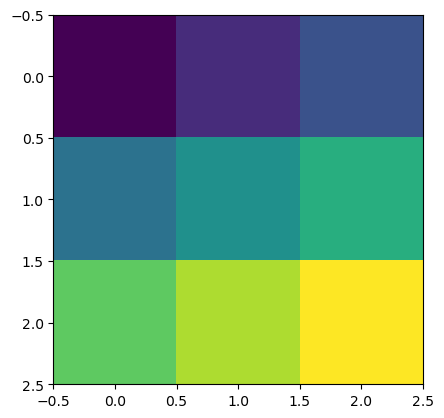

In [17]:
fig = plt.figure()
plt.imshow(arr_2d)
plt.show()

`imshow` is used most of the times to display images.

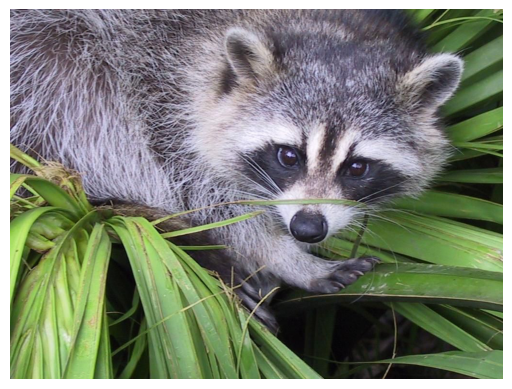

In [25]:
# Read images into numpy array. Usually imageio would be used here.
# see https://imageio.github.io/
from scipy.datasets import face
img = face(gray=False)  # set gray=True for grayscale

fig = plt.figure()
plt.imshow(img)
plt.axis("off")
plt.show()

For visualizing matrices, `matshow` provides better defaults, e.g. axis labelling.

<Figure size 640x480 with 0 Axes>

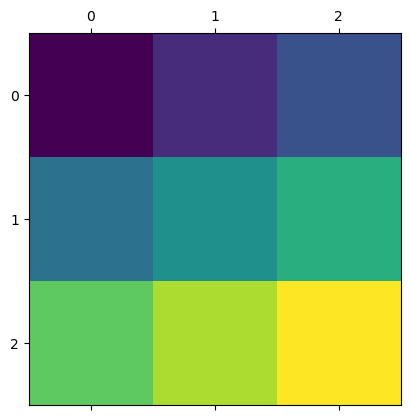

In [26]:
fig = plt.figure()
plt.matshow(arr_2d)
plt.show()

### Colorbars

Just seeing the colors does not necessarily tell us something about the values beneath. Let's add a colorbar to the figure to display what colors correspond to values of `data` we've plotted. 

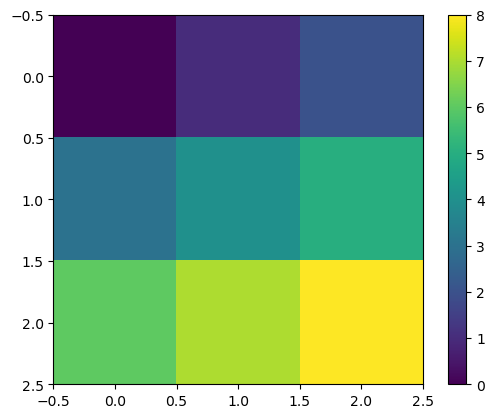

In [27]:
fig = plt.figure()
im = plt.imshow(arr_2d)
fig.colorbar(im)
plt.show()

In [28]:
arr_2d

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

The colorbar is usually placed next to the plot (from which it "steels" some space).  It is also possible to create an own `Axes` object to place the colorbar (more on `Axes` next week).

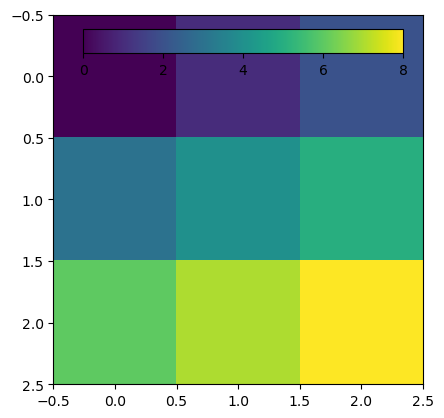

In [29]:
fig = plt.figure()
im = plt.imshow(arr_2d)
cax = fig.add_axes([0.27, 0.8, 0.5, 0.05])
fig.colorbar(im, cax=cax, orientation='horizontal')
plt.show()

### Shared parameters for `imshow`, `pcolormesh`, `contour`, `scatter`, etc
  
  As we mentioned earlier, any plotting method that creates a `ScalarMappable` will have some common kwargs.  The ones you'll use the most frequently are:
  
  * `cmap` : The colormap (or name of the colormap) used to display the input.  (We'll go over the different colormaps in the next section.)
  * `vmin` : The minimum data value that will correspond to the "bottom" of the colormap (defaults to the minimum of your input data).
  * `vmax` : The maximum data value that will correspond to the "top" of the colormap (defaults to the maximum of your input data).
  * `norm` : A `Normalize` instance to control how the data values are mapped to the colormap. By default, this will be a linear scaling between `vmin` and `vmax`, but other norms are available (e.g. `LogNorm`, `PowerNorm`, etc).
  
`vmin` and `vmax` are particularly useful.  Quite often, you'll want the colors to be mapped to a set range of data values, which aren't the min/max of your input data. For example, you might want a symmetric ranges of values around 0.

As an example of that, let's use a divergent colormap on some example data. Note how the colormap is **not** centered at zero.

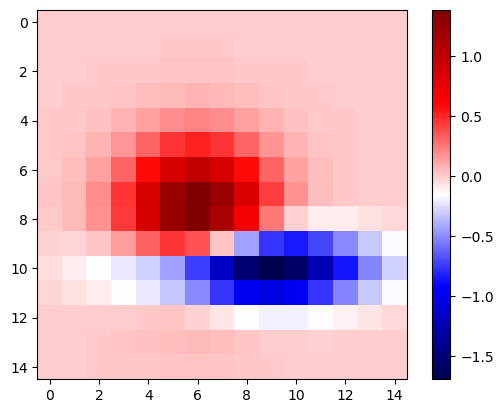

In [30]:
from matplotlib.cbook import get_sample_data
data = get_sample_data('axes_grid/bivariate_normal.npy')

fig, ax = plt.subplots()
im = ax.imshow(data, cmap='seismic')
fig.colorbar(im)
plt.show()

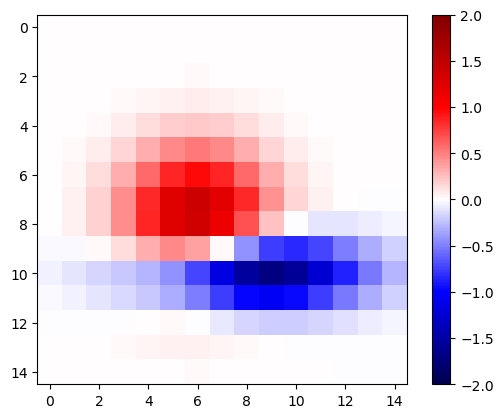

In [31]:
fig, ax = plt.subplots()
im = ax.imshow(data, cmap='seismic', vmin=-2, vmax=2)
fig.colorbar(im)
plt.show()

## Scatter for n-dimensional data
`scatter` allows to map several dimensions to different aesthetics such as x-postion, color, size and shape.

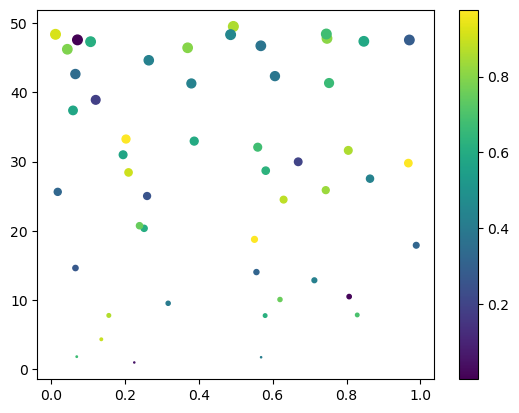

In [32]:
n = 50
x1 = np.random.random(n)
x2 = np.random.random(n) * 50
x3 = np.random.random(n)
y = x1 + x2 + x3

fig = plt.figure()
sc = plt.scatter(x=x1, y=y, s=x2, c=x3, marker='o')
fig.colorbar(sc)
plt.show()

There are lots of different markers mpl supports which can help to emphasize different distributions. Have a look at https://matplotlib.org/stable/api/markers_api.html#module-matplotlib.markers to get a list of marker options.

In [ ]:
num = 100
x1 = np.random.normal(-1, 2, num)
y1 = np.random.normal(3, 4, num)
x2 = np.random.normal(3, 2, num)
y2 = np.random.normal(1, 1, num)

fig, ax = plt.subplots()
ax.scatter(x1, y1, marker='.')
ax.scatter(x2, y2, marker='x')
plt.show()

## Visualizing statistical distributions

Draw samples from a normal distribution.

In [33]:
μ = 0
σ = 1
num_samples = 1000
dist = np.random.normal(μ, σ, num_samples)

**Side note on unicode characters as variables.** Since Python 3 we can use any unicode character such as μ and σ as variables. This can make sense in scientific programming if strong naming conventions exist. A good example is mean and standard deviation of a normal distribution. To easily obtain common characters you can use latex style and type e.g. `\mu` followed by <kbd>tab</kbd> to obtain μ. However, do not overuse this. Clearly named characters are often easier to read.

### Histograms
Histograms a great way to visualize univariate distributions. The data is divided into equally sized bins. Then we count how many data points fall into each bin. Finally, we draw a bar with the width of the corresponding bin and the height of the count.

The standard histogram looks like this.

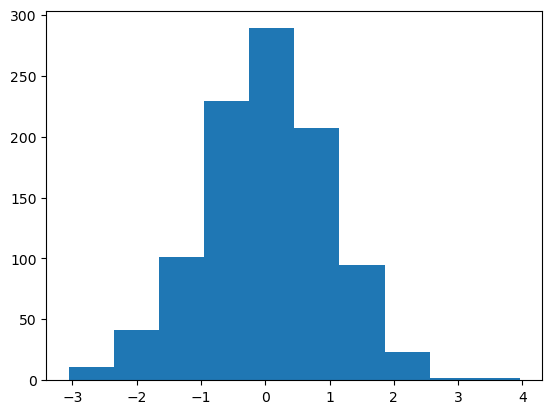

In [34]:
fig = plt.figure()
plt.hist(dist)
plt.show()

We can control the number of bins.

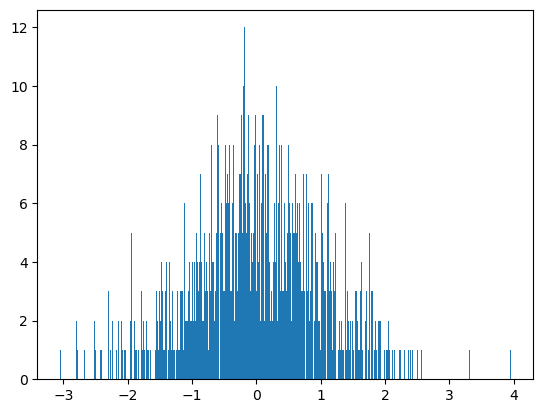

In [35]:
fig = plt.figure()
plt.hist(dist, bins=500)
plt.show()

Or let it be automatically determined.

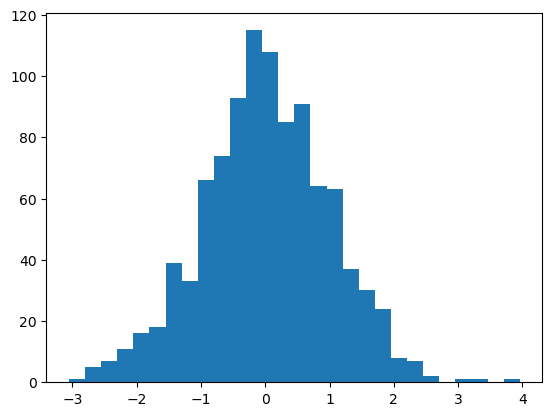

In [36]:
fig = plt.figure()
plt.hist(dist, bins='auto')
plt.show()

Using `density=True` will create a normalized histogram that can be interpreted as a probability density. 

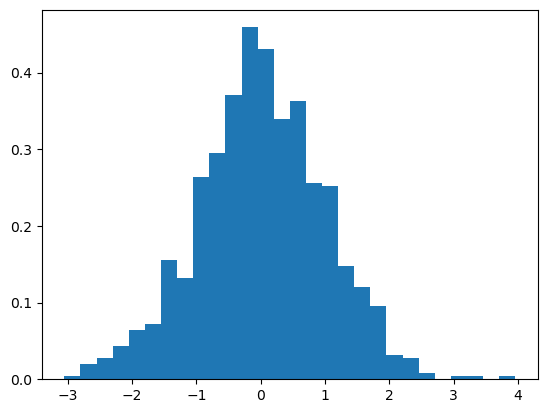

In [37]:
fig = plt.figure()
plt.hist(dist, bins='auto', density=True)
plt.show()

### Boxplots
Boxplots are another standard way to summarize univariate distributions. They give a compact visual description of important *summary statistics*. 
A box is drawn at the 25% and 75% quantile, that is where most of the data is. Additionally, the median is marked by a line inside the box.
The *whiskers* extend 1.5 times the *inter quartile range* beyond the quartiles. Every point beyond that is drawn individually as a *flier* or *outlier*. See also https://flowingdata.com/2008/02/15/how-to-read-and-use-a-box-and-whisker-plot/ for a nice illustration.

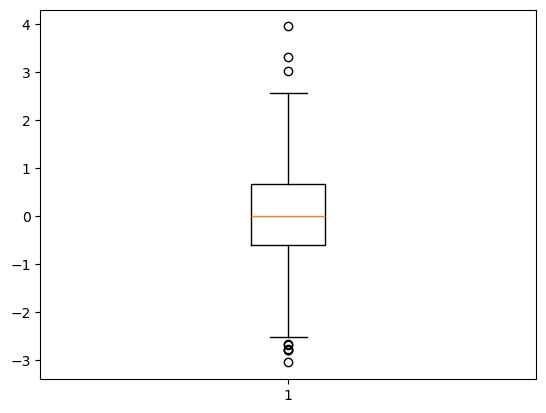

In [38]:
fig = plt.figure()
plt.boxplot(dist)
plt.show()

`boxplot` can also be used to display several distributions at once.

In [39]:
import reprlib # This is for obtaining printable versions of large data sets.
means = [0, -1, 2.5, 4.3, -3.6]
sigmas = [1.2, 5, 3, 1.5, 2]
# Each distribution has a different number of samples.
nums = [150, 1000, 100, 200, 500]

dists = [np.random.normal(*args) for args in zip(means, sigmas, nums)]
reprlib.repr(dists)

'[array([ 1.051...23276943e-01]), array([ 2.996...56217073e+00]), array([ 5.861...  3.13430491]), array([1.0326..., 3.01359952]), array([-4.157...83776857e-01])]'

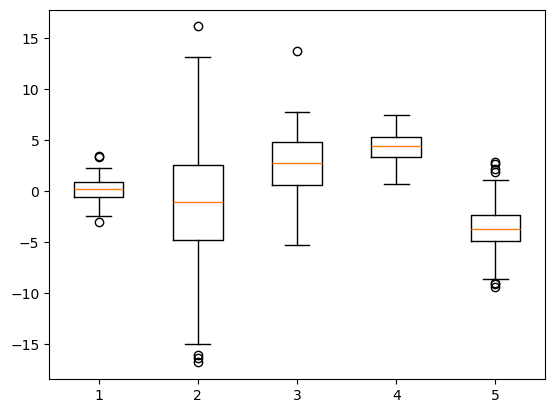

In [40]:
fig = plt.figure()
plt.boxplot(dists)
plt.show()

### Violinplots
Violinplots are a third common way to visualize distributions. For violinplots a *kernel density estimate* is computed for the whole range of data. This gives a smooth estimate of the probabiliy density function underlying the data.
The `violinplot`function behaves similar to `boxplot`. For further information, have a look at https://en.wikipedia.org/wiki/Violin_plot.

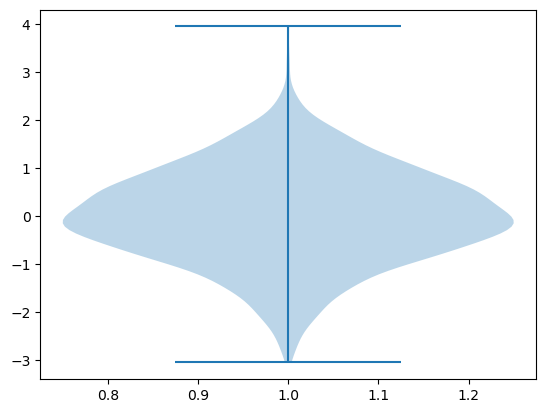

In [41]:
fig = plt.figure()
plt.violinplot(dist)
plt.show()

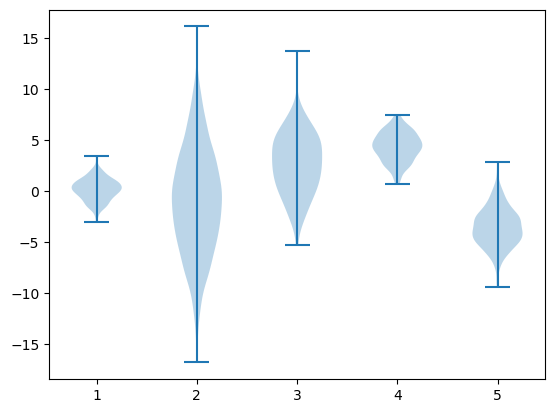

In [42]:
fig = plt.figure()
plt.violinplot(dists)
plt.show()

### Pie charts
Pie charts a well known way to visualize categorical distributions.

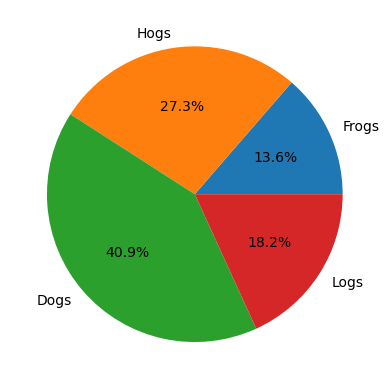

In [43]:
# Pie chart, where the slices will be ordered and plotted counter-clockwise:
labels = 'Frogs', 'Hogs', 'Dogs', 'Logs'
sizes = [15, 30, 45, 20]

fig = plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.show()

We will cover more advanced and more convenient methods for statistical visualization in a later lecture.

## Annotating plots
Especially for scientific figures, you often want to hightlight the part of a plot that supports your hypothesis. With maplotlib you have the full flexibility to do this using `annotate`. By default it will just add text at certain x, y coordinate.  

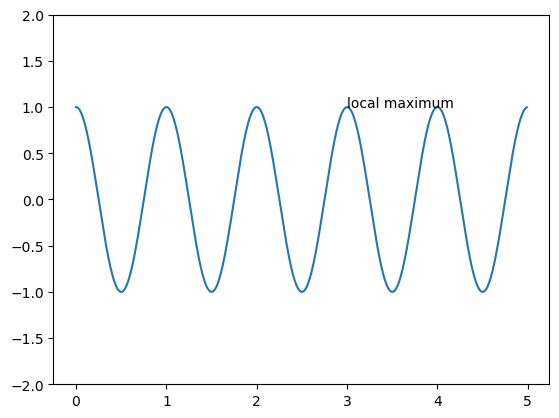

In [44]:
fig = plt.figure()

t = np.arange(0.0, 5.0, 0.01)
s = np.cos(2*np.pi*t)

# Plot a line and add some simple annotations
line, = plt.plot(t, s)
plt.annotate('local maximum', xy=(3, 1))
plt.ylim(-2, 2)
plt.show()

We can also put the text at a different x, y-coordinat using the `xytext` argument.

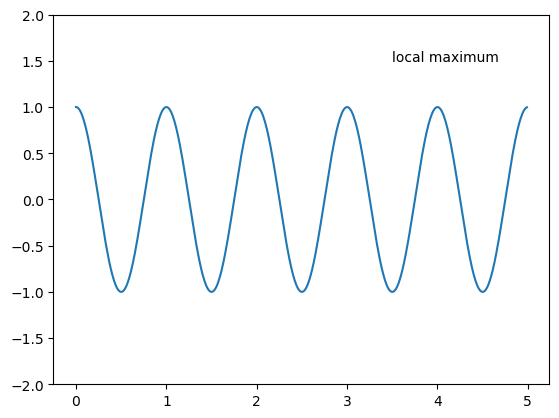

In [45]:
fig = plt.figure()

t = np.arange(0.0, 5.0, 0.01)
s = np.cos(2*np.pi*t)

line, = plt.plot(t, s)
plt.annotate('local maximum', xy=(3, 1), xytext=(3.5, 1.5))

plt.ylim(-2, 2)
plt.show()

Now that we have two x, y - coordinates we can connect them using arrows.

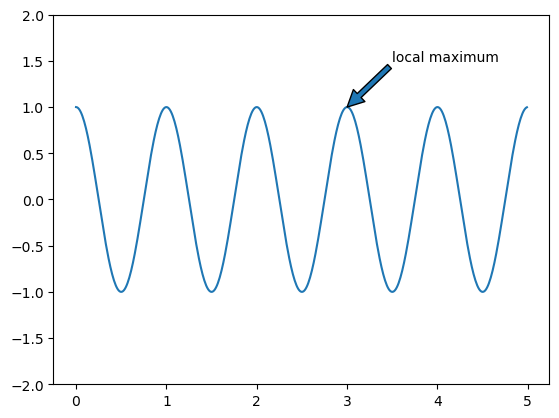

In [46]:
fig = plt.figure()

t = np.arange(0.0, 5.0, 0.01)
s = np.cos(2*np.pi*t)

# Plot a line and add some simple annotations
line, = plt.plot(t, s)
plt.annotate('local maximum', xy=(3, 1), xytext=(3.5, 1.5), arrowprops=dict())

plt.ylim(-2, 2)
plt.show()

If we have to, we can go very fancy on the arrow styles. See https://matplotlib.org/tutorials/text/annotations.html for a detailed overview.

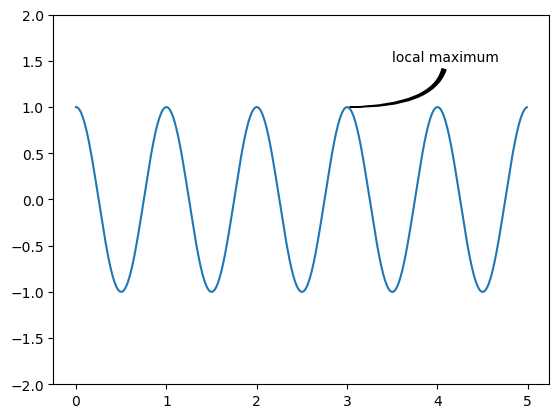

In [47]:
fig = plt.figure()

t = np.arange(0.0, 5.0, 0.01)
s = np.cos(2*np.pi*t)

# Plot a line and add some simple annotations
line, = plt.plot(t, s)
plt.annotate('local maximum', xy=(3, 1), xytext=(3.5, 1.5),
             arrowprops=dict(arrowstyle='wedge', connectionstyle="angle3", facecolor="black"))

plt.ylim(-2, 2)
plt.show()

# Anatomy of a "Plot"
Matplotlib is a large project and can seem daunting at first. However, by learning the components, it should begin to feel much smaller and more approachable.

People use "plot" to mean many different things.  Here, we'll be using a consistent terminology (mirrored by the names of the underlying classes, etc):

<img src="images/figure_axes_axis_labeled.png">

* The ``Figure`` is the top-level container in this hierarchy.
  - It is the overall window/page that everything is drawn on.
  - You can have multiple independent figures and ``Figure``s can contain multiple ``Axes``. 

* Most plotting ocurs on an ``Axes``.
  - The axes is effectively the area that we plot data on and any ticks/labels/etc associated with it.
  - Usually we'll set up an Axes with a call to ``subplot``
  - `subplot` places Axes on a regular grid, so in most cases, ``Axes`` and ``Subplot`` are synonymous.

* Each ``Axes`` has an ``XAxis`` and a ``YAxis``.
  - These contain the ticks, tick locations, labels, etc.
  - we will usually not touch ``Axis`` directly, instead use other function to control ticks, tick labels, and data limits
  - however, it is worth mentioning here to explain where the term ``Axes`` comes from.

## Working with `Figures` and `Axes`

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
fig = plt.figure()

Awww, nothing happened! This is because by default mpl will not show anything until told to do so, as we mentioned earlier in the "backend" discussion.

Instead, we'll need to call ``plt.show()``

In [ ]:
plt.show()

Still nothing. That is because the notebook does not want to show empty figures. In a plain python script, you would actually get an empty figure here. To actually see the figure in the notebook, we need to add some axes...

## Axes

All plotting is done with respect to an [`Axes`](http://matplotlib.org/api/axes_api.html#matplotlib.axes.Axes). An *Axes* is made up of [`Axis`](http://matplotlib.org/api/axis_api.html#matplotlib.axis.Axis) objects and many other things. An *Axes* object must belong to a *Figure* (and only one *Figure*). Most commands you will ever issue will be with respect to this *Axes* object.

Typically, you'll set up a `Figure`, and then add an `Axes` to it. 

You can use `fig.add_axes`, but in most cases, you'll find that adding a subplot will fit your needs perfectly. (Again a "subplot" is just an axes on a grid system.) 

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
plt.show()

You can control the size of the figure through the ``figsize`` argument, which expects a tuple of ``(width, height)`` in inches. 

BTW: A really useful utility function is [`figaspect`](http://matplotlib.org/api/figure_api.html?highlight=figaspect#matplotlib.figure.figaspect)

In [ ]:
fig = plt.figure(figsize=(5, 10))  # Twice as high as wide.
ax = fig.add_subplot(111)
plt.show()

Matplotlib's objects typically have lots of "explicit setters" -- in other words, functions that start with ``set_<something>`` and control a particular option. 

To demonstrate this (and as an example of IPython's tab-completion), try typing `ax.set_` in a code cell, then hit the `<Tab>` key.  You'll see a long list of `Axes` methods that start with `set`.

For example, we could have written the third line above as:

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.set_xlim([0.5, 4.5])
ax.set_ylim([-2, 8])
ax.set_title("An Example Axes")
ax.set_ylabel("Y-Axis")
ax.set_xlabel("X-Axis")
plt.show()

Clearly this can get repitive quickly.  Therefore, Matplotlib's `set` method can be very handy.  It takes each kwarg you pass it and tries to call the corresponding "setter".  For example, `ax.set(foo='bar')` would call `ax.set_foo('bar')`.

Note that the `set` method doesn't just apply to `Axes`; it applies to more-or-less all matplotlib objects.

However, there are cases where you'll want to use things like `ax.set_xlabel('Some Label', size=25)` to control other options for a particular function.

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.set(
    xlim=[0.5, 4.5], 
    ylim=[-2, 8], 
    title='An Example Axes',
    ylabel='Y-Axis', 
    xlabel='X-Axis',
)
plt.show()

## Axes methods (object oriented interface) vs. pyplot (state machine interface)

Up to now we used the `matplotlib.pyplot` functions for plotting.  These function implicitly create an `Axes` object and implicitly calls methods of that object.
Just about all methods of an `Axes` object exist as a function in the `pyplot` module (and vice-versa). 

For example, when calling `plt.xlim(1, 10)`, `pyplot` calls `ax.set_xlim(1, 10)` on whichever `Axes` is *current*. Here is an equivalent version of the above example using just `pyplot`.

In [ ]:
plt.figure()
plt.plot([10, 20, 25, 35])
plt.show()

The same plot can be obtained using the object oriented `Axes` interface:

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot([10, 20, 25, 35])
plt.show()

In general (except for very simple plots) it is preferable to uses the `Axes` interface:
* when doing more complicated plots, or working within larger scripts, you will want to explicitly pass around the *Axes* and/or *Figure* object to operate upon.
* The advantage of keeping which axes we're working with very clear in our code will become more obvious when we start to have multiple axes in one figure.
* [PEP20](http://www.python.org/dev/peps/pep-0020/) "The Zen of Python" says: "Explicit is better than implicit"

## Multiple Axes

A figure can have more than one `Axes` on it.  If you want your axes to be on a regular grid system, then it's easiest to use `plt.subplots(...)` to create a figure and add the axes to it automatically.

For example:

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2)
plt.show()

`plt.subplots(...)` created a new figure and added 4 subplots to it.  The `axes` object that was returned is a 2D numpy object array.  Each item in the array is one of the subplots.  They're laid out as you see them on the figure.  

Therefore, when we want to work with one of these axes, we can index the `axes` array and use that item's methods.

For example:

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2)
axes[0, 0].set(title="Upper Left")
axes[0, 1].set(title="Upper Right")
axes[1, 0].set(title="Lower Left")
axes[1, 1].set(title="Lower Right")

# tight_layout makes sure titles and tick labels do not overlap.
fig.tight_layout()

plt.show()

One really nice thing about `plt.subplots()` is that when it's called with no arguments, it creates a new figure with a single subplot. 

Any time you see something like

```
fig = plt.figure()
ax = fig.add_subplot(111)
```

You can replace it with:

```
fig, ax = plt.subplots()
```

We'll be using that approach for the rest of the examples.  It's much cleaner.  

However, keep in mind that we're still creating a figure and adding axes to it.  When we start making plot layouts that can't be described by `subplots`, we'll go back to creating the figure first and then adding axes to it one-by-one.

Speaking of titles, you can also set a supertitle for an entire figure.

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2)
axes[0, 0].set(title="Upper Left")
axes[0, 1].set(title="Upper Right")
axes[1, 0].set(title="Lower Left")
axes[1, 1].set(title="Lower Right")

# tight_layout makes sure titles and tick labels do not overlap.
fig.tight_layout()
fig.suptitle("Four subplots")

plt.show()

## Subplot Spacing
The spacing between the subplots can be adjusted using [`fig.subplots_adjust()`](http://matplotlib.org/api/pyplot_api.html?#matplotlib.pyplot.subplots_adjust). Play around with the example below to see how the different arguments affect the spacing.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(9, 9))
fig.subplots_adjust(wspace=0.3, hspace=0.7,
                   left=0.125, right=0.8,
                   top=0.7,    bottom=0.2)
plt.show()

A common "gotcha" is that the labels are not automatically adjusted to avoid overlapping those of another subplot. Matplotlib does not currently have any sort of robust layout engine, as it is a design decision to minimize the amount of "magical plotting". We intend to let users have complete, 100% control over their plots. LaTeX users would be quite familiar with the amount of frustration that can occur with automatic placement of figures in their documents.

That said, there have been some efforts to develop tools that users can use to help address the most common compaints. The "[Tight Layout](http://matplotlib.org/users/tight_layout_guide.html)" feature, when invoked, will attempt to resize margins and subplots so that nothing overlaps.

If you have multiple subplots, and want to avoid overlapping titles/axis labels/etc, `fig.tight_layout` is a great way to do so:

In [ ]:
def example_plot(ax):
    ax.plot([1, 2])
    ax.set_xlabel('x-label', fontsize=16)
    ax.set_ylabel('y-label', fontsize=8)
    ax.set_title('Title', fontsize=24)

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
example_plot(ax1)
example_plot(ax2)
example_plot(ax3)
example_plot(ax4)

plt.show()

In [ ]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
example_plot(ax1)
example_plot(ax2)
example_plot(ax3)
example_plot(ax4)

# Tight layout enabled.
fig.tight_layout()

plt.show()

# How to speak "MPL"

Control plots and figures: the substance and vocabulary of the library. 

## Colors
This is, perhaps, the most important piece of vocabulary in Matplotlib. Given that Matplotlib is a plotting library, colors are associated with everything that is plotted in your figures. Matplotlib supports a [very robust language](http://matplotlib.org/api/colors_api.html#module-matplotlib.colors) for specifying colors that should be familiar to a wide variety of users.

By default matplotlib will choose different colors when combining data on the same axes.

In [ ]:
t = np.arange(0.0, 5.0, 0.2)
fig, ax = plt.subplots()
ax.plot(t, t, linewidth=5)
ax.plot(t, t**2, linewidth=5)
ax.plot(t, t**3, linewidth=5)
plt.show()

### Colornames
First, colors can be given as strings. For very basic colors, you can even get away with just a single letter:

- b: blue
- g: green
- r: red
- c: cyan
- m: magenta
- y: yellow
- k: black
- w: white

Other colornames that are allowed are the HTML/CSS colornames such as "burlywood" and "chartreuse". See the [full list](https://www.w3schools.com/colors/colors_names.asp) of the 147 colornames.

### Hex values
Colors can also be specified by supplying a HTML/CSS hex string, such as `'#0000FF'` for blue. Support for an optional alpha channel was added for v2.0. For more information about hex colors have a look at https://en.wikipedia.org/wiki/Web_colors#Hex_triplet.

In [ ]:
t = np.arange(0.0, 5.0, 0.2)
fig, ax = plt.subplots()
ax.plot(t, t, linewidth=5, color='#00ffff')
ax.plot(t, t**2, linewidth=5, color='#ff00ff')
ax.plot(t, t**3, linewidth=5, color='#ffcc00')
plt.show()

### 256 Shades of Gray
A gray level can be given instead of a color by passing a string representation of a number between 0 and 1 (inclusive). `'0.0'` is black, while `'1.0'` is white. `'0.75'` would be a light shade of gray.


In [ ]:
t = np.arange(0.0, 5.0, 0.2)
fig, ax = plt.subplots()
ax.plot(t, t, linewidth=5, color='1.0')
ax.plot(t, t**2, linewidth=5, color='0.5')
ax.plot(t, t**3, linewidth=5, color='0.0')
plt.show()

### RGB[A] tuples
You may come upon instances where the previous ways of specifying colors do not work. This can sometimes happen in some of the deeper, stranger levels of the library. When all else fails, the universal language of colors for matplotlib is the RGB[A] tuple. This is the "Red", "Green", "Blue", and sometimes "Alpha" tuple of floats in the range of [0, 1]. One means full saturation of that channel, so a red RGBA tuple would be `(1.0, 0.0, 0.0, 1.0)`, whereas a partly transparent green RGBA tuple would be `(0.0, 1.0, 0.0, 0.75)`.  The documentation will usually specify whether it accepts RGB or RGBA tuples. Sometimes, a list of tuples would be required for multiple colors, and you can even supply a Nx3 or Nx4 numpy array in such cases.

In functions such as `plot()` and `scatter()`, while it may appear that they can take a color specification, what they really need is a "format specification", which includes color as part of the format. Unfortunately, such specifications are string only and so RGB[A] tuples are not supported for such arguments (but you can still pass an RGB[A] tuple for a "color" argument).

Oftentimes there is a separate argument for "alpha" where-ever you can specify a color. The value for "alpha" will usually take precedence over the alpha value in the RGBA tuple. There is no easy way around this inconsistency.

In [ ]:
t = np.arange(0.0, 3.0, 0.2)
fig, ax = plt.subplots()
ax.plot(t, t, linewidth=5, color=(0, 0, 1))
ax.plot(t, t**2, linewidth=5, color=(0, 0.5, 0.5))
ax.plot(t, t**3, linewidth=5, color=(0, 0, 1, 0.3))
# the alpha value can also be specified as an additional kwarg
ax.plot(t, t**4, linewidth=5, color=(0, 1, 1), alpha=0.2)
plt.show()

### Cycle references
With the advent of fancier color cycles coming from the many available styles, users needed a way to reference those colors in the style without explicitly knowing what they are. So, in v2.0, the ability to reference the first 10 iterations of the color cycle was added. Whereever one could specify a color, you can supply a 2 character string of 'C#'. So, 'C0' would be the first color, 'C1' would be the second, and so on and so forth up to 'C9'.

In [ ]:
t = np.arange(0.0, 5.0, 0.2)
fig, ax = plt.subplots()
ax.plot(t, t, linewidth=5)
ax.plot(t, t**2, linewidth=5)
ax.plot(t, t**3, linewidth=5)
plt.show()

In [ ]:
t = np.arange(0.0, 5.0, 0.2)
fig, ax = plt.subplots()
ax.plot(t, t, linewidth=5, color='C2')
ax.plot(t, t**2, linewidth=5, color='C3')
ax.plot(t, t**3, linewidth=5, color='C0')
plt.show()

## Markers
[Markers](http://matplotlib.org/api/markers_api.html) are commonly used in [`plot()`](http://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.plot) and [`scatter()`](http://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.scatter) plots, but also show up elsewhere. There is a wide set of markers available, and custom markers can even be specified.

marker     |  description  | marker    |  description    |marker    |  description  | marker    |  description  
:----------|:--------------| :---------|:--------------  |:---------|:--------------| :---------|:--------------
"."        |  point        | "+"       |  plus           |","       |  pixel        | "x"       |  cross
"o"        |  circle       | "D"       |  diamond        |"d"       |  thin_diamond |           |
"8"        |  octagon      | "s"       |  square         |"p"       |  pentagon     | "\*"      |  star
"&#124;"   |  vertical line| "\_"      | horizontal line | "h"      |  hexagon1     | "H"       |  hexagon2
0          |  tickleft     | 4         |  caretleft      |"<"       | triangle_left | "3"       |  tri_left
1          |  tickright    | 5         |  caretright     |">"       | triangle_right| "4"       |  tri_right
2          |  tickup       | 6         |  caretup        |"^"       | triangle_up   | "2"       |  tri_up
3          |  tickdown     | 7         |  caretdown      |"v"       | triangle_down | "1"       |  tri_down
"None"     |  nothing      | `None`    |  default        |" "       |  nothing      |""         |  nothing


In [ ]:
t = np.arange(0.0, 5.0, 0.2)
fig, ax = plt.subplots()
ax.plot(t, t, '.', linewidth=5)
ax.plot(t, t**2, 'o', linewidth=5)
ax.plot(t, t**3, marker='+', linewidth=1) # With explicit arguments, you can set maker and linestyle separately.
ax.plot(t, -t, ls='', marker='v', linewidth=5) 
plt.show()

## Linestyles
Line styles are about as commonly used as colors. There are a few predefined linestyles available to use. Note that there are some advanced techniques to specify some custom line styles. [Here](http://matplotlib.org/1.3.0/examples/lines_bars_and_markers/line_demo_dash_control.html) is an example of a custom dash pattern.

linestyle          | description
-------------------|------------------------------
'-'                | solid
'--'               | dashed
'-.'               | dashdot
':'                | dotted
'None'             | draw nothing
' '                | draw nothing
''                 | draw nothing

Also, don't mix up ".-" (line with dot markers) and "-." (dash-dot line) when using the ``plot`` function!

In [ ]:
t = np.arange(0.0, 5.0, 0.2)
fig, ax = plt.subplots()
ax.plot(t, t, linestyle='-', linewidth=5)
ax.plot(t, t**2, linestyle='--', linewidth=5)
ax.plot(t, t**3, linestyle='-.', linewidth=5)
ax.plot(t, -t, linestyle=':', linewidth=5)
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.bar([1, 2, 3, 4], [10, 20, 15, 13], linestyle='--', edgecolor='r', linewidth=4)
plt.show()

## Colormaps
Another very important property of many figures is the colormap. The job of a colormap is to relate a scalar value to a color. In addition to the regular portion of the colormap, an "over", "under" and "bad" color can be optionally defined as well. NaNs will trigger the "bad" part of the colormap.

As we all know, we create figures in order to convey information visually to our readers. There is much care and consideration that have gone into the design of these colormaps. Your choice in which colormap to use depends on what you are displaying. In mpl, the "jet" colormap has historically been used by default, but it will often not be the colormap you would want to use. Much discussion has taken place on the mailing lists with regards to what colormap should be default. The v2.0 release of Matplotlib adopted a new default colormap, 'viridis', along with some other stylistic changes to the defaults.

[Here is the talk](https://www.youtube.com/watch?v=xAoljeRJ3lU) by Nathaniel Smith and Stéfan van der Walt at SciPy 2015 that does an excelent job explaining colormaps and how the new perceptual uniform colormaps where designed.



In [ ]:
def plot_cmap(name, value_range=(0, 1)):
    gradient = np.linspace(*value_range, 256)
    gradient = np.vstack((gradient, gradient))
    fig, ax = plt.subplots(figsize=plt.figaspect(0.1))
    ax.imshow(gradient, aspect='auto', cmap=plt.get_cmap(name), vmin=0, vmax=1)
    pos = list(ax.get_position().bounds)
    x_text = pos[0] - 0.01
    y_text = pos[1] + pos[3]/2.
    ax.set_title(name, fontsize=20)
    ax.axis("off")

plot_cmap("jet")

In [ ]:
plot_cmap("viridis")

Here you can find the full gallery of all the pre-defined colormaps, organized by the types of data they are usually used for: https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html

## Mathtext
Oftentimes, you just simply need that superscript or some other math text in your labels. Matplotlib provides a very easy way to do this for those familiar with LaTeX. Any text that is surrounded by dollar signs will be treated as "[mathtext](http://matplotlib.org/users/mathtext.html#mathtext-tutorial)". Do note that because backslashes are prevelent in LaTeX, it is often a good idea to prepend an `r` to your string literal so that Python will not treat the backslashes as escape characters.

In [ ]:
print(r"a\nb")

In [ ]:
fig, ax = plt.subplots()
ax.scatter([1, 2, 3, 4], [4, 3, 2, 1])
ax.spines['top'].set(visible=False)  # Removing spines so they don't intersect with the title. tight_layout() is not sufficient here.
ax.spines['right'].set(visible=False)
ax.set_title(r'$\sigma_i=\frac{3}{5}$', fontsize=25)
plt.show()

# Limits, Legends and Layouts

In this section, we'll focus on what happens around the edges of the axes:  Ticks, ticklabels, limits, layouts, and legends.

## Legends

As you've seen in some of the examples so far, the X and Y axis can also be labeled, as well as the subplot itself via the title. 

However, another thing you can label is the line/point/bar/etc that you plot.  You can provide a label to your plot, which allows your legend to automatically build itself. 

In [ ]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4], [10, 20, 25, 30])  # Philadelphia
ax.plot([1, 2, 3, 4], [30, 23, 13, 4])  # Boston
ax.set(ylabel='Temperature (deg C)', xlabel='Time', title='A tale of two cities')
plt.show()

In [ ]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4], [10, 20, 25, 30], label='Philadelphia')
ax.plot([1, 2, 3, 4], [30, 23, 13, 4], label='Boston')
ax.set(ylabel='Temperature (deg C)', xlabel='Time', title='A tale of two cities')
ax.legend()
plt.show()

The keyword argument `loc` allows to position the legend at different positions. The `'best'` argument is the default one which automatically chooses the location which overlaps the plot elements as little as possbile.

| Location String | Location Code |
| --- | --- |
| best | 0 |
| upper right | 1 |
| upper left | 2 |
| lower left | 3 |
| lower right | 4 |
| right | 5 |
| center left | 6 |
| center right | 7 |
| lower center | 8 |
| upper center | 9 |
| center | 10 |

In [ ]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4], [10, 20, 25, 30], label='Philadelphia')
ax.plot([1, 2, 3, 4], [30, 23, 13, 4], label='Boston')
ax.set(ylabel='Temperature (deg C)', xlabel='Time', title='A tale of two cities')
ax.legend(loc="center")
plt.show()

## Ticks, Tick Lines, Tick Labels and Tickers
This is a constant source of confusion:

* A Tick is the *location* of a Tick Label.
* A Tick Line is the line that denotes the location of the tick.
* A Tick Label is the text that is displayed at that tick.
* A [`Ticker`](http://matplotlib.org/api/ticker_api.html#module-matplotlib.ticker) automatically determines the ticks for an Axis and formats the tick labels.

[`tick_params()`](http://matplotlib.org/api/axes_api.html#matplotlib.axes.Axes.tick_params) is often used to help configure your tickers.

In [ ]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3, 4], [10, 20, 25, 35])

# Manually set ticks and tick labels *on the x-axis* (note ax.xaxis.set, not ax.set!)
ax.xaxis.set(ticks=range(1, 5), ticklabels=[3, 100, -12, "foo"]) 

# Make the y-ticks a bit longer and go both in and out...
ax.tick_params(axis='y', direction='in', length=10)

plt.show()

In [ ]:
data = [('apples', 2), ('oranges', 3), ('peaches', 1)]
fruit, value = zip(*data)

fig, ax = plt.subplots()
x = np.arange(len(fruit))
ax.bar(x, value, align='center', color='gray')
ax.set(xticks=x, xticklabels=fruit)
plt.show()

# mplot3d
By taking advantage of Matplotlib's z-order layering engine, mplot3d emulates 3D plotting by projecting 3D data into 2D space, layer by layer. While it isn't going to replace any of the true 3D plotting libraries anytime soon, its goal is to allow for Matplotlib users to produce 3D plots with the same amount of simplicity as 2D plots.

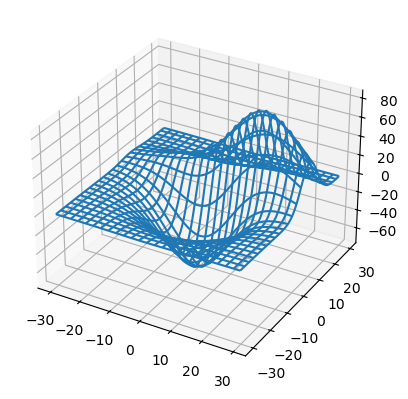

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D, axes3d

fig, ax = plt.subplots(1, 1, subplot_kw={'projection': '3d'})
X, Y, Z = axes3d.get_test_data(0.05)
ax.plot_wireframe(X, Y, Z, rstride=5, cstride=5)

plt.show()